**Advanced Modeling**

Sabse pehle project me use hone wali saari required libraries import kar rahe hain.

In [1]:
# Data handling ke liye pandas aur numpy import kar rahe hain
import pandas as pd
import numpy as np

# Data visualization ke liye matplotlib import kar rahe hain
import matplotlib.pyplot as plt

# Dataset ko train aur test me split karne ke liye import kar rahe hain
from sklearn.model_selection import train_test_split

# Feature scaling ke liye StandardScaler import kar rahe hain
from sklearn.preprocessing import StandardScaler

# Warning messages ko hide karne ke liye warnings import kar rahe hain
import warnings

# Saari warnings ignore kar rahe hain
warnings.filterwarnings("ignore")

Step 2 – Load the Cleaned Dataset

Part 1 me banayi gayi cleaned dataset ko load kar rahe hain.

In [2]:
# Cleaned dataset ko CSV file se load kar rahe hain
df = pd.read_csv("cleaned_data.csv")

# Dataset ka shape display kar rahe hain
print("Dataset Shape:")
print(df.shape)

# Dataset ki first 5 rows display kar rahe hain
display(df.head())

Dataset Shape:
(7000, 25)


,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


Step 3 – Check Dataset Information

In [3]:
# Dataset ki complete information display kar rahe hain
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   participant_id                       7000 non-null   object 
 1   age                                  7000 non-null   int64  
 2   gender                               7000 non-null   object 
 3   occupation                           7000 non-null   object 
 4   region                               7000 non-null   object 
 5   most_used_platform                   7000 non-null   object 
 6   platforms_used_count                 7000 non-null   int64  
 7   daily_screen_hours                   7000 non-null   float64
 8   daily_notifications                  7000 non-null   int64  
 9   night_time_use                       7000 non-null   object 
 10  minutes_to_first_check_after_waking  7000 non-null   int64  
 11  primary_p

Step 4 – Create Regression and Classification Targets

Part 2 ki tarah same target variables dobara create kar rahe hain.

In [4]:
# Regression target variable select kar rahe hain
y_reg = df["low_mood_score_0to27"]

# Regression target se binary classification target create kar rahe hain
y_clf = (y_reg > y_reg.median()).astype(int)

# Feature matrix create kar rahe hain
X = df.drop(columns=["participant_id", "low_mood_score_0to27"])

# Feature matrix aur target ka shape display kar rahe hain
print("Feature Matrix Shape:", X.shape)
print("Classification Target Shape:", y_clf.shape)

Feature Matrix Shape: (7000, 23)
Classification Target Shape: (7000,)


Step 5 – Encode Ordinal Features

Ab ordinal categorical columns par Label Encoding apply kar rahe hain.

In [5]:
# Night time use ke liye ordinal mapping define kar rahe hain
night_time_mapping = {
    "Never": 0,
    "Sometimes": 1,
    "Often": 2,
    "Every night": 3
}

# Wellbeing band ke liye ordinal mapping define kar rahe hain
wellbeing_mapping = {
    "At-risk": 0,
    "Moderate": 1,
    "Good": 2
}

# Ordinal encoding apply kar rahe hain
X["night_time_use"] = X["night_time_use"].map(night_time_mapping)
X["wellbeing_band"] = X["wellbeing_band"].map(wellbeing_mapping)

Step 6 – Apply One-Hot Encoding

Ab remaining nominal categorical columns par One-Hot Encoding apply kar rahe hain.

In [6]:
# Remaining categorical columns identify kar rahe hain
categorical_columns = X.select_dtypes(include="object").columns

# One-Hot Encoding apply kar rahe hain
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

# Encoded dataset ka shape display kar rahe hain
print("Encoded Feature Matrix Shape:")
print(X.shape)

Encoded Feature Matrix Shape:
(7000, 45)


Step 7 – Train-Test Split

Ab dataset ko training aur testing sets me split kar rahe hain.

In [7]:
# Training aur testing dataset create kar rahe hain
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42
)

# Dataset ka shape display kar rahe hain
print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape :", X_test.shape)

Training Feature Shape: (5600, 45)
Testing Feature Shape : (1400, 45)


Step 8 – Feature Scaling

Ab StandardScaler ka use karke training aur testing features scale kar rahe hain.

In [8]:
# StandardScaler ka object create kar rahe hain
scaler = StandardScaler()

# Training data par scaler fit kar rahe hain
X_train_scaled = scaler.fit_transform(X_train)

# Testing data ko same scaler se transform kar rahe hain
X_test_scaled = scaler.transform(X_test)

# Scaling complete hone ka message display kar rahe hain
print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


**TASK 1 :- Decision Tree baseline:**

Step 1 – Import Decision Tree Classifier

Ab Decision Tree model ko train karne ke liye required library import kar rahe hain.

In [9]:
# Decision Tree Classifier import kar rahe hain
from sklearn.tree import DecisionTreeClassifier

# Accuracy calculate karne ke liye accuracy_score import kar rahe hain
from sklearn.metrics import accuracy_score

Step 2 – Create the Decision Tree Model

Ab default settings ke saath Decision Tree model create kar rahe hain.

In [10]:
# Default Decision Tree model create kar rahe hain
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Model display kar rahe hain
print(decision_tree_model)

DecisionTreeClassifier(random_state=42)


Step 3 – Train the Decision Tree Model

Ab training dataset ka use karke Decision Tree model train kar rahe hain.

In [11]:
# Decision Tree model ko training data par train kar rahe hain
decision_tree_model.fit(
    X_train_scaled,
    y_clf_train
)

# Success message display kar rahe hain
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


Step 4 – Predict on Training Data

Ab training dataset ke liye prediction kar rahe hain taaki training accuracy calculate kar sakein.

In [12]:
# Training dataset ke liye prediction kar rahe hain
y_train_pred = decision_tree_model.predict(
    X_train_scaled
)

# First 10 predictions display kar rahe hain
print("First 10 Training Predictions:")
print(y_train_pred[:10])

First 10 Training Predictions:
[1 0 0 0 0 1 1 0 1 1]


Step 5 – Predict on Testing Data

Ab testing dataset ke liye prediction kar rahe hain.

In [13]:
# Testing dataset ke liye prediction kar rahe hain
y_test_pred = decision_tree_model.predict(
    X_test_scaled
)

# First 10 predictions display kar rahe hain
print("First 10 Testing Predictions:")
print(y_test_pred[:10])

First 10 Testing Predictions:
[1 0 0 0 1 0 1 1 1 0]


Step 6 – Calculate Training Accuracy

Ab training accuracy calculate kar rahe hain.

In [14]:
# Training accuracy calculate kar rahe hain
train_accuracy = accuracy_score(
    y_clf_train,
    y_train_pred
)

# Training accuracy display kar rahe hain
print(f"Training Accuracy : {train_accuracy:.4f}")

Training Accuracy : 1.0000


Step 7 – Calculate Testing Accuracy

Ab testing accuracy calculate kar rahe hain.

In [15]:
# Testing accuracy calculate kar rahe hain
test_accuracy = accuracy_score(
    y_clf_test,
    y_test_pred
)

# Testing accuracy display kar rahe hain
print(f"Testing Accuracy : {test_accuracy:.4f}")

Testing Accuracy : 0.5643


Step 8 – Compare Training and Testing Accuracy

Ab check kar rahe hain ki model overfitting show kar raha hai ya nahi.

In [16]:
# Training aur testing accuracy compare kar rahe hain
print("=" * 50)
print("Decision Tree Performance")
print("=" * 50)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")

# Overfitting check kar rahe hain
if train_accuracy - test_accuracy > 0.05:
    print("\nModel shows signs of overfitting.")
else:
    print("\nModel generalizes well.")

Decision Tree Performance
Training Accuracy : 1.0000
Testing Accuracy  : 0.5643

Model shows signs of overfitting.


**Task 2 – Controlled Decision Tree**

Step 1 – Create the Controlled Decision Tree Model

In [17]:
# Controlled Decision Tree model create kar rahe hain
controlled_tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

# Model display kar rahe hain
print(controlled_tree_model)

DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)


Step 2 – Train the Controlled Decision Tree

In [18]:
# Controlled Decision Tree model ko training data par train kar rahe hain
controlled_tree_model.fit(
    X_train_scaled,
    y_clf_train
)

# Success message display kar rahe hain
print("Controlled Decision Tree model trained successfully.")

Controlled Decision Tree model trained successfully.


Step 3 – Predict on Training Data

In [19]:
# Training dataset ke liye prediction kar rahe hain
controlled_train_pred = controlled_tree_model.predict(
    X_train_scaled
)

# First 10 predictions display kar rahe hain
print("First 10 Training Predictions:")
print(controlled_train_pred[:10])

First 10 Training Predictions:
[1 1 0 0 0 1 1 0 0 1]


Step 4 – Predict on Testing Data

In [20]:
# Testing dataset ke liye prediction kar rahe hain
controlled_test_pred = controlled_tree_model.predict(
    X_test_scaled
)

# First 10 predictions display kar rahe hain
print("First 10 Testing Predictions:")
print(controlled_test_pred[:10])

First 10 Testing Predictions:
[0 1 0 0 1 0 0 1 1 0]


Step 5 – Calculate Training Accuracy

In [21]:
# Training accuracy calculate kar rahe hain
controlled_train_accuracy = accuracy_score(
    y_clf_train,
    controlled_train_pred
)

# Training accuracy display kar rahe hain
print(f"Training Accuracy : {controlled_train_accuracy:.4f}")

Training Accuracy : 0.6466


Step 6 – Calculate Testing Accuracy

In [22]:
# Testing accuracy calculate kar rahe hain
controlled_test_accuracy = accuracy_score(
    y_clf_test,
    controlled_test_pred
)

# Testing accuracy display kar rahe hain
print(f"Testing Accuracy : {controlled_test_accuracy:.4f}")

Testing Accuracy : 0.6214


Step 7 – Compare Both Decision Tree Models

In [23]:
# Dono Decision Tree models ka comparison table bana rahe hain
comparison_df = pd.DataFrame({

    "Model": [
        "Default Decision Tree",
        "Controlled Decision Tree"
    ],

    "Training Accuracy": [
        train_accuracy,
        controlled_train_accuracy
    ],

    "Testing Accuracy": [
        test_accuracy,
        controlled_test_accuracy
    ]

})

# Comparison table display kar rahe hain
print("Decision Tree Comparison")
print(comparison_df)

Decision Tree Comparison
                      Model  Training Accuracy  Testing Accuracy
0     Default Decision Tree           1.000000          0.564286
1  Controlled Decision Tree           0.646607          0.621429


Step 8 – Check Overfitting

In [24]:
# Default aur Controlled model ka train-test gap compare kar rahe hain
default_gap = train_accuracy - test_accuracy
controlled_gap = controlled_train_accuracy - controlled_test_accuracy

print("=" * 60)
print("Overfitting Analysis")
print("=" * 60)

print(f"Default Tree Gap    : {default_gap:.4f}")
print(f"Controlled Tree Gap : {controlled_gap:.4f}")

if controlled_gap < default_gap:
    print("\nControlled Decision Tree reduces overfitting.")
else:
    print("\nControlled Decision Tree does not reduce overfitting.")

Overfitting Analysis
Default Tree Gap    : 0.4357
Controlled Tree Gap : 0.0252

Controlled Decision Tree reduces overfitting.


Task 3 – Gini vs Entropy Comparison

Step 1 – Create the Gini Decision Tree

In [25]:
# Gini criterion ke saath Decision Tree model create kar rahe hain
gini_tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

# Model display kar rahe hain
print(gini_tree_model)

DecisionTreeClassifier(max_depth=5, random_state=42)


Step 2 – Train the Gini Decision Tree

In [26]:
# Gini Decision Tree model ko training data par train kar rahe hain
gini_tree_model.fit(
    X_train_scaled,
    y_clf_train
)

# Success message display kar rahe hain
print("Gini Decision Tree trained successfully.")

Gini Decision Tree trained successfully.


Step 3 – Calculate Gini Test Accuracy

In [27]:
# Testing dataset ke liye prediction kar rahe hain
gini_predictions = gini_tree_model.predict(
    X_test_scaled
)

# Test accuracy calculate kar rahe hain
gini_accuracy = accuracy_score(
    y_clf_test,
    gini_predictions
)

# Accuracy display kar rahe hain
print(f"Gini Test Accuracy : {gini_accuracy:.4f}")

Gini Test Accuracy : 0.6214


Step 4 – Create the Entropy Decision Tree

In [28]:
# Entropy criterion ke saath Decision Tree model create kar rahe hain
entropy_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

# Model display kar rahe hain
print(entropy_tree_model)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)


Step 5 – Train the Entropy Decision Tree

In [29]:
# Entropy Decision Tree model ko training data par train kar rahe hain
entropy_tree_model.fit(
    X_train_scaled,
    y_clf_train
)

# Success message display kar rahe hain
print("Entropy Decision Tree trained successfully.")

Entropy Decision Tree trained successfully.


Step 6 – Calculate Entropy Test Accuracy

In [30]:
# Testing dataset ke liye prediction kar rahe hain
entropy_predictions = entropy_tree_model.predict(
    X_test_scaled
)

# Test accuracy calculate kar rahe hain
entropy_accuracy = accuracy_score(
    y_clf_test,
    entropy_predictions
)

# Accuracy display kar rahe hain
print(f"Entropy Test Accuracy : {entropy_accuracy:.4f}")

Entropy Test Accuracy : 0.6307


Step 7 – Compare Gini and Entropy

In [31]:
# Gini aur Entropy models ka comparison table bana rahe hain
comparison_table = pd.DataFrame({

    "Criterion": [
        "Gini",
        "Entropy"
    ],

    "Test Accuracy": [
        gini_accuracy,
        entropy_accuracy
    ]

})

# Comparison table display kar rahe hain
print("=" * 50)
print("Gini vs Entropy Comparison")
print("=" * 50)

print(comparison_table)

Gini vs Entropy Comparison
  Criterion  Test Accuracy
0      Gini       0.621429
1   Entropy       0.630714


Step 8 – Identify the Better Criterion

In [32]:
# Better performing criterion identify kar rahe hain
if gini_accuracy > entropy_accuracy:

    print("\nGini criterion achieved better test accuracy.")

elif entropy_accuracy > gini_accuracy:

    print("\nEntropy criterion achieved better test accuracy.")

else:

    print("\nBoth criteria achieved the same test accuracy.")


Entropy criterion achieved better test accuracy.


**Task 4 – Random Forest Classifier**

Step 1 – Import Required Libraries

In [33]:
# Random Forest Classifier import kar rahe hain
from sklearn.ensemble import RandomForestClassifier

# ROC-AUC calculate karne ke liye required metrics import kar rahe hain
from sklearn.metrics import roc_auc_score

Step 2 – Create the Random Forest Mode

In [34]:
# Random Forest model create kar rahe hain
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# Model display kar rahe hain
print(random_forest_model)

RandomForestClassifier(max_depth=10, random_state=42)


Step 3 – Train the Random Forest Mode

In [35]:
# Random Forest model ko training dataset par fit kar rahe hain
random_forest_model.fit(
    X_train_scaled,
    y_clf_train
)

# Success message display kar rahe hain
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Step 4 – Predict on Training Data

In [36]:
# Training dataset ke liye prediction generate kar rahe hain
rf_train_predictions = random_forest_model.predict(
    X_train_scaled
)

# First 10 predictions display kar rahe hain
print("First 10 Training Predictions:")
print(rf_train_predictions[:10])

First 10 Training Predictions:
[1 0 0 0 0 1 1 0 1 1]


Step 5 – Predict on Testing Data

In [37]:
# Testing dataset ke liye prediction generate kar rahe hain
rf_test_predictions = random_forest_model.predict(
    X_test_scaled
)

# First 10 predictions display kar rahe hain
print("First 10 Testing Predictions:")
print(rf_test_predictions[:10])

First 10 Testing Predictions:
[0 1 0 0 0 0 0 1 0 0]


Step 6 – Calculate Training Accuracy

In [38]:
# Training accuracy calculate kar rahe hain
rf_train_accuracy = accuracy_score(
    y_clf_train,
    rf_train_predictions
)

# Training accuracy display kar rahe hain
print(f"Training Accuracy : {rf_train_accuracy:.4f}")

Training Accuracy : 0.8505


Step 7 – Calculate Testing Accuracy

In [39]:
# Testing accuracy calculate kar rahe hain
rf_test_accuracy = accuracy_score(
    y_clf_test,
    rf_test_predictions
)

# Testing accuracy display kar rahe hain
print(f"Testing Accuracy : {rf_test_accuracy:.4f}")

Testing Accuracy : 0.6300


Step 8 – Calculate ROC-AUC Score

In [40]:
# Positive class ki prediction probabilities generate kar rahe hain
rf_probabilities = random_forest_model.predict_proba(
    X_test_scaled
)[:, 1]

# ROC-AUC score calculate kar rahe hain
rf_auc = roc_auc_score(
    y_clf_test,
    rf_probabilities
)

# ROC-AUC score display kar rahe hain
print(f"ROC-AUC Score : {rf_auc:.4f}")

ROC-AUC Score : 0.6735


– Feature Importance

Step 9 – Extract Feature Importance Scores

In [41]:
# Random Forest model se feature importance scores extract kar rahe hain
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": random_forest_model.feature_importances_

})

# Importance ke according descending order me sort kar rahe hain
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Index ko reset kar rahe hain
feature_importance = feature_importance.reset_index(drop=True)

# First 5 rows display kar rahe hain
display(feature_importance.head())

,Feature,Importance
0,daily_screen_hours,0.172018
1,daily_notifications,0.101370
2,avg_sleep_hours,0.065828
3,anxiety_score_0to27,0.058841
4,minutes_to_first_check_after_waking,0.049309


Step 10 – Display Top 5 Important Features

In [42]:
# Top 5 important features select kar rahe hain
top_5_features = feature_importance.head(5)

# Top 5 features display kar rahe hain
print("Top 5 Important Features")

display(top_5_features)

Top 5 Important Features


,Feature,Importance
0,daily_screen_hours,0.172018
1,daily_notifications,0.101370
2,avg_sleep_hours,0.065828
3,anxiety_score_0to27,0.058841
4,minutes_to_first_check_after_waking,0.049309


Step 11 – Display Lowest 5 Important Features

In [43]:
# Lowest 5 important features select kar rahe hain
lowest_5_features = feature_importance.tail(5)

# Lowest 5 features display kar rahe hain
print("Lowest 5 Important Features")

display(lowest_5_features)

Lowest 5 Important Features


,Feature,Importance
40,most_used_platform_Reddit,0.004444
41,most_used_platform_LinkedIn,0.004230
42,gender_Non-binary,0.003926
43,occupation_Retired,0.003361
44,gender_Prefer not to say,0.003279


Step 12 – Display Random Forest Performance Summary

In [44]:
# Random Forest performance summary display kar rahe hain
print("=" * 60)
print("Random Forest Performance Summary")
print("=" * 60)

print(f"Training Accuracy : {rf_train_accuracy:.4f}")
print(f"Testing Accuracy  : {rf_test_accuracy:.4f}")
print(f"ROC-AUC Score     : {rf_auc:.4f}")

Random Forest Performance Summary
Training Accuracy : 0.8505
Testing Accuracy  : 0.6300
ROC-AUC Score     : 0.6735


**Task 4a – Gradient Boosting Classifier**

Step 1 – Import Gradient Boosting Classifier

In [45]:
# Gradient Boosting Classifier import kar rahe hain
from sklearn.ensemble import GradientBoostingClassifier

Step 2 – Create the Gradient Boosting Model

In [46]:
# Gradient Boosting model create kar rahe hain
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Model display kar rahe hain
print(gradient_boosting_model)

GradientBoostingClassifier(random_state=42)


Step 3 – Train the Gradient Boosting Model

In [47]:
# Gradient Boosting model ko training dataset par fit kar rahe hain
gradient_boosting_model.fit(
    X_train_scaled,
    y_clf_train
)

# Success message display kar rahe hain
print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


Step 4 – Predict on Training Data

In [48]:
# Training dataset ke liye prediction generate kar rahe hain
gb_train_predictions = gradient_boosting_model.predict(
    X_train_scaled
)

# First 10 predictions display kar rahe hain
print("First 10 Training Predictions:")
print(gb_train_predictions[:10])

First 10 Training Predictions:
[1 1 0 0 0 1 1 0 1 1]


Step 5 – Predict on Testing Data

In [49]:
# Testing dataset ke liye prediction generate kar rahe hain
gb_test_predictions = gradient_boosting_model.predict(
    X_test_scaled
)

# First 10 predictions display kar rahe hain
print("First 10 Testing Predictions:")
print(gb_test_predictions[:10])

First 10 Testing Predictions:
[0 1 0 0 0 0 0 1 1 0]


Step 6 – Calculate Training Accuracy

In [50]:
# Training accuracy calculate kar rahe hain
gb_train_accuracy = accuracy_score(
    y_clf_train,
    gb_train_predictions
)

# Training accuracy display kar rahe hain
print(f"Training Accuracy : {gb_train_accuracy:.4f}")

Training Accuracy : 0.6911


Step 7 – Calculate Testing Accuracy

In [51]:
# Testing accuracy calculate kar rahe hain
gb_test_accuracy = accuracy_score(
    y_clf_test,
    gb_test_predictions
)

# Testing accuracy display kar rahe hain
print(f"Testing Accuracy : {gb_test_accuracy:.4f}")

Testing Accuracy : 0.6279


Step 8 – Calculate ROC-AUC Score

In [52]:
# Positive class ki prediction probabilities generate kar rahe hain
gb_probabilities = gradient_boosting_model.predict_proba(
    X_test_scaled
)[:, 1]

# ROC-AUC score calculate kar rahe hain
gb_auc = roc_auc_score(
    y_clf_test,
    gb_probabilities
)

# ROC-AUC score display kar rahe hain
print(f"ROC-AUC Score : {gb_auc:.4f}")

ROC-AUC Score : 0.6843


Step 9 – Display Performance Summary

In [53]:
# Gradient Boosting performance summary display kar rahe hain
print("=" * 60)
print("Gradient Boosting Performance Summary")
print("=" * 60)

print(f"Training Accuracy : {gb_train_accuracy:.4f}")
print(f"Testing Accuracy  : {gb_test_accuracy:.4f}")
print(f"ROC-AUC Score     : {gb_auc:.4f}")

Gradient Boosting Performance Summary
Training Accuracy : 0.6911
Testing Accuracy  : 0.6279
ROC-AUC Score     : 0.6843


**Task 4b – Feature Ablation Study**

Step 1 – Store the Lowest 5 Feature Names

In [54]:
# Lowest 5 important feature names ko list me store kar rahe hain
lowest_feature_names = lowest_5_features["Feature"].tolist()

# Lowest feature names display kar rahe hain
print("Lowest 5 Features:")

for feature in lowest_feature_names:
    print(feature)

Lowest 5 Features:
most_used_platform_Reddit
most_used_platform_LinkedIn
gender_Non-binary
occupation_Retired
gender_Prefer not to say


Step 2 – Remove the Lowest 5 Features

In [55]:
# Training dataset se lowest importance features remove kar rahe hain
X_train_reduced = X_train.drop(
    columns=lowest_feature_names
)

# Testing dataset se lowest importance features remove kar rahe hain
X_test_reduced = X_test.drop(
    columns=lowest_feature_names
)

# Reduced dataset ka shape display kar rahe hain
print("Reduced Training Shape :", X_train_reduced.shape)
print("Reduced Testing Shape  :", X_test_reduced.shape)

Reduced Training Shape : (5600, 40)
Reduced Testing Shape  : (1400, 40)


Step 3 – Scale the Reduced Dataset

Ab reduced dataset ke liye naya StandardScaler use kar rahe hain.

In [56]:
# Reduced dataset ke liye naya scaler create kar rahe hain
reduced_scaler = StandardScaler()

# Reduced training dataset ko fit aur transform kar rahe hain
X_train_reduced_scaled = reduced_scaler.fit_transform(
    X_train_reduced
)

# Reduced testing dataset ko transform kar rahe hain
X_test_reduced_scaled = reduced_scaler.transform(
    X_test_reduced
)

# Success message display kar rahe hain
print("Reduced dataset scaling completed.")

Reduced dataset scaling completed.


Step 4 – Create the Reduced Random Forest Model

In [57]:
# Reduced Random Forest model create kar rahe hain
reduced_random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# Model display kar rahe hain
print(reduced_random_forest)

RandomForestClassifier(max_depth=10, random_state=42)


Step 5 – Train the Reduced Model

In [58]:
# Reduced Random Forest model ko training data par fit kar rahe hain
reduced_random_forest.fit(
    X_train_reduced_scaled,
    y_clf_train
)

# Success message display kar rahe hain
print("Reduced Random Forest model trained successfully.")

Reduced Random Forest model trained successfully.


Step 6 – Calculate Reduced Model ROC-AUC

In [59]:
# Reduced model ki prediction probabilities generate kar rahe hain
reduced_probabilities = reduced_random_forest.predict_proba(
    X_test_reduced_scaled
)[:, 1]

# Reduced model ka ROC-AUC score calculate kar rahe hain
reduced_auc = roc_auc_score(
    y_clf_test,
    reduced_probabilities
)

# Reduced model ka ROC-AUC display kar rahe hain
print(f"Reduced Model ROC-AUC : {reduced_auc:.4f}")

Reduced Model ROC-AUC : 0.6688


Step 7 – Compare Both Models

In [60]:
# Full aur Reduced Random Forest models ka comparison table bana rahe hain
ablation_results = pd.DataFrame({

    "Model": [
        "Full Random Forest",
        "Reduced Random Forest"
    ],

    "ROC-AUC": [
        rf_auc,
        reduced_auc
    ]

})

# Comparison table display kar rahe hain
print("=" * 60)
print("Feature Ablation Study")
print("=" * 60)

display(ablation_results)

Feature Ablation Study


,Model,ROC-AUC
0,Full Random Forest,0.673535
1,Reduced Random Forest,0.668756


Step 8 – Interpret the Result

In [61]:
# Full aur Reduced models ka ROC-AUC compare kar rahe hain
if reduced_auc >= rf_auc:

    print("The removed features were likely uninformative.")
    print("The reduced model maintained or improved performance.")

else:

    print("The removed features contributed to model performance.")
    print("Removing them reduced the ROC-AUC score.")

The removed features contributed to model performance.
Removing them reduced the ROC-AUC score.


**Task 5 – Cross Validation**

Step 1 – Import Required Libraries

In [62]:
# Cross Validation ke liye required libraries import kar rahe hain
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

# Logistic Regression import kar rahe hain
from sklearn.linear_model import LogisticRegression

Step 2 – Create Cross Validation Object

In [63]:
# 5-Fold Stratified Cross Validation object create kar rahe hain
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Success message display kar rahe hain
print("5-Fold Stratified Cross Validation Created Successfully.")

5-Fold Stratified Cross Validation Created Successfully.


Step 3 – Create Logistic Regression Model

In [64]:
# Logistic Regression model create kar rahe hain
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Model display kar rahe hain
print(logistic_model)

LogisticRegression(max_iter=1000, random_state=42)


Step 4 – Cross Validate Logistic Regression

In [65]:
# Logistic Regression ke liye Cross Validation perform kar rahe hain
logistic_scores = cross_val_score(
    logistic_model,
    X_train,
    y_clf_train,
    cv=cv,
    scoring="roc_auc"
)

# Mean aur Standard Deviation calculate kar rahe hain
logistic_mean = logistic_scores.mean()
logistic_std = logistic_scores.std()

# Results display kar rahe hain
print(f"Mean ROC-AUC : {logistic_mean:.4f}")
print(f"Standard Deviation : {logistic_std:.4f}")

Mean ROC-AUC : 0.6903
Standard Deviation : 0.0152


Step 5 – Cross Validate Controlled Decision Tree

In [66]:
# Controlled Decision Tree ke liye Cross Validation perform kar rahe hain
decision_tree_scores = cross_val_score(
    controlled_tree_model,
    X_train,
    y_clf_train,
    cv=cv,
    scoring="roc_auc"
)

# Mean aur Standard Deviation calculate kar rahe hain
decision_tree_mean = decision_tree_scores.mean()
decision_tree_std = decision_tree_scores.std()

# Results display kar rahe hain
print(f"Mean ROC-AUC : {decision_tree_mean:.4f}")
print(f"Standard Deviation : {decision_tree_std:.4f}")

Mean ROC-AUC : 0.6718
Standard Deviation : 0.0145


Step 6 – Cross Validate Random Forest

In [67]:
# Random Forest ke liye Cross Validation perform kar rahe hain
random_forest_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_clf_train,
    cv=cv,
    scoring="roc_auc"
)

# Mean aur Standard Deviation calculate kar rahe hain
random_forest_mean = random_forest_scores.mean()
random_forest_std = random_forest_scores.std()

# Results display kar rahe hain
print(f"Mean ROC-AUC : {random_forest_mean:.4f}")
print(f"Standard Deviation : {random_forest_std:.4f}")

Mean ROC-AUC : 0.6783
Standard Deviation : 0.0115


Step 7 – Cross Validate Gradient Boosting

In [68]:
# Gradient Boosting ke liye Cross Validation perform kar rahe hain
gradient_boosting_scores = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_clf_train,
    cv=cv,
    scoring="roc_auc"
)

# Mean aur Standard Deviation calculate kar rahe hain
gradient_boosting_mean = gradient_boosting_scores.mean()
gradient_boosting_std = gradient_boosting_scores.std()

# Results display kar rahe hain
print(f"Mean ROC-AUC : {gradient_boosting_mean:.4f}")
print(f"Standard Deviation : {gradient_boosting_std:.4f}")

Mean ROC-AUC : 0.6891
Standard Deviation : 0.0113


Step 8 – Compare All Models

In [69]:
# Sabhi models ka Cross Validation comparison table bana rahe hain
cv_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Controlled Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Mean ROC-AUC": [
        logistic_mean,
        decision_tree_mean,
        random_forest_mean,
        gradient_boosting_mean
    ],

    "Standard Deviation": [
        logistic_std,
        decision_tree_std,
        random_forest_std,
        gradient_boosting_std
    ]

})

# Results ko descending order me sort kar rahe hain
cv_results = cv_results.sort_values(
    by="Mean ROC-AUC",
    ascending=False
).reset_index(drop=True)

# Final comparison table display kar rahe hain
print("=" * 70)
print("5-Fold Cross Validation Results")
print("=" * 70)

display(cv_results)

5-Fold Cross Validation Results


,Model,Mean ROC-AUC,Standard Deviation
0,Logistic Regression,0.690259,0.015216
1,Gradient Boosting,0.689096,0.011341
2,Random Forest,0.678274,0.011528
3,Controlled Decision Tree,0.671816,0.014508


**Task 6 – Hyperparameter Tuning using GridSearchCV**

Step 1 – Import Required Libraries

In [70]:
# Grid Search aur Cross Validation ke liye required libraries import kar rahe hain
from sklearn.model_selection import GridSearchCV

# Missing values handle karne ke liye SimpleImputer import kar rahe hain
from sklearn.impute import SimpleImputer

# Pipeline create karne ke liye make_pipeline import kar rahe hain
from sklearn.pipeline import make_pipeline

Step 2 – Create the Machine Learning Pipeline

In [71]:
# Machine Learning pipeline create kar rahe hain
pipeline = make_pipeline(

    SimpleImputer(strategy="median"),

    StandardScaler(),

    RandomForestClassifier(random_state=42)

)

# Pipeline display kar rahe hain
print(pipeline)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])


Step 3 – Define the Parameter Grid

In [72]:
# Grid Search ke liye parameter grid define kar rahe hain
param_grid = {

    "randomforestclassifier__n_estimators": [
        50,
        100,
        200
    ],

    "randomforestclassifier__max_depth": [
        5,
        10,
        None
    ],

    "randomforestclassifier__min_samples_leaf": [
        1,
        5
    ]

}

# Parameter grid display kar rahe hain
print(param_grid)

{'randomforestclassifier__n_estimators': [50, 100, 200], 'randomforestclassifier__max_depth': [5, 10, None], 'randomforestclassifier__min_samples_leaf': [1, 5]}


Step 4 – Create the Grid Search Object

In [73]:
# Grid Search object create kar rahe hain
grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    cv=cv,

    scoring="roc_auc",

    n_jobs=-1

)

# Success message display kar rahe hain
print("GridSearchCV object created successfully.")

GridSearchCV object created successfully.


Step 5 – Train Grid Search

In [74]:
# Grid Search ko training dataset par fit kar rahe hain
grid_search.fit(

    X_train,

    y_clf_train

)

# Success message display kar rahe hain
print("Grid Search completed successfully.")

Grid Search completed successfully.


Step 6 – Display the Best Parameters

In [75]:
# Best parameters display kar rahe hain
print("Best Parameters")

print(grid_search.best_params_)

Best Parameters
{'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 5, 'randomforestclassifier__n_estimators': 200}


Step 7 – Display the Best ROC-AUC Score

In [76]:
# Best ROC-AUC score display kar rahe hain
print("Best ROC-AUC Score")

print(round(grid_search.best_score_, 4))

Best ROC-AUC Score
0.6838


Step 8 – Calculate Total Configurations

In [77]:
# Total parameter combinations calculate kar rahe hain
total_combinations = (

    len(param_grid["randomforestclassifier__n_estimators"])

    *

    len(param_grid["randomforestclassifier__max_depth"])

    *

    len(param_grid["randomforestclassifier__min_samples_leaf"])

)

# Total models evaluated calculate kar rahe hain
total_models = total_combinations * 5

# Results display kar rahe hain
print(f"Parameter Combinations : {total_combinations}")

print(f"Total Models Evaluated : {total_models}")

Parameter Combinations : 18
Total Models Evaluated : 90


Step 9 – Save the Best Pipeline

In [78]:
# Best pipeline ko save kar rahe hain
best_pipeline = grid_search.best_estimator_

# Success message display kar rahe hain
print("Best pipeline saved successfully.")

Best pipeline saved successfully.


**Task 7 – Manual Learning Curve**

Step 1 – Define Training Fractions

In [79]:
# Training dataset ke fractions define kar rahe hain
training_fractions = [
    0.2,
    0.4,
    0.6,
    0.8,
    1.0
]

# Empty list create kar rahe hain jisme results store honge
learning_curve_results = []

Step 2 – Train the Best Pipeline on Different Training Sizes

In [80]:
# Har training fraction ke liye loop chala rahe hain
for fraction in training_fractions:

    # Current training size calculate kar rahe hain
    sample_size = int(fraction * len(X_train))

    # Training subset create kar rahe hain
    X_subset = X_train.iloc[:sample_size]

    y_subset = y_clf_train.iloc[:sample_size]

    # Best pipeline ko current subset par train kar rahe hain
    best_pipeline.fit(
        X_subset,
        y_subset
    )

    # Training probabilities generate kar rahe hain
    train_probabilities = best_pipeline.predict_proba(
        X_subset
    )[:, 1]

    # Testing probabilities generate kar rahe hain
    test_probabilities = best_pipeline.predict_proba(
        X_test
    )[:, 1]

    # Training AUC calculate kar rahe hain
    train_auc = roc_auc_score(
        y_subset,
        train_probabilities
    )

    # Testing AUC calculate kar rahe hain
    test_auc = roc_auc_score(
        y_clf_test,
        test_probabilities
    )

    # Current result list me store kar rahe hain
    learning_curve_results.append([
        fraction,
        train_auc,
        test_auc
    ])

Step 3 – Create the Learning Curve Table

In [81]:
# Learning curve results ka DataFrame create kar rahe hain
learning_curve_df = pd.DataFrame(

    learning_curve_results,

    columns=[
        "Training Fraction",
        "Training AUC",
        "Testing AUC"
    ]

)

# Learning curve table display kar rahe hain
print("Manual Learning Curve")

display(learning_curve_df)

Manual Learning Curve


,Training Fraction,Training AUC,Testing AUC
0,0.2,0.960955,0.659933
1,0.4,0.931400,0.667530
2,0.6,0.908534,0.669678
3,0.8,0.889399,0.672993
4,1.0,0.879357,0.671855


Step 4 – Plot the Learning Curve

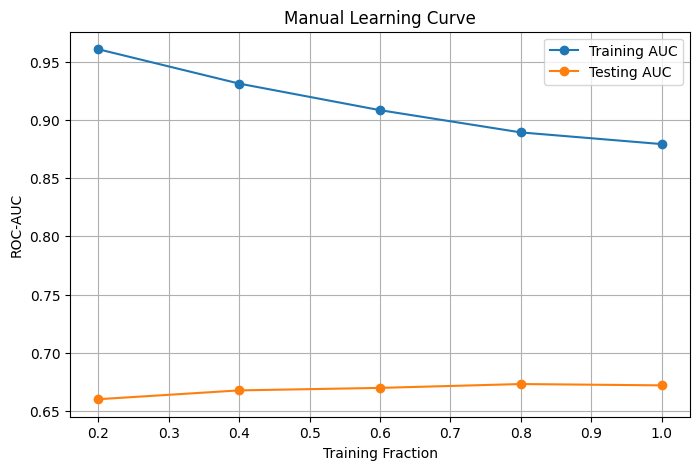

In [82]:
# Figure size set kar rahe hain
plt.figure(figsize=(8, 5))

# Training AUC plot kar rahe hain
plt.plot(
    learning_curve_df["Training Fraction"],
    learning_curve_df["Training AUC"],
    marker="o",
    label="Training AUC"
)

# Testing AUC plot kar rahe hain
plt.plot(
    learning_curve_df["Training Fraction"],
    learning_curve_df["Testing AUC"],
    marker="o",
    label="Testing AUC"
)

# X-axis label set kar rahe hain
plt.xlabel("Training Fraction")

# Y-axis label set kar rahe hain
plt.ylabel("ROC-AUC")

# Graph ka title set kar rahe hain
plt.title("Manual Learning Curve")

# Legend display kar rahe hain
plt.legend()

# Grid enable kar rahe hain
plt.grid(True)

# Graph display kar rahe hain
plt.show()

**Task 8 – Serialize the Best Model**

Step 1 – Import Joblib

In [83]:
# Trained model ko save aur load karne ke liye joblib import kar rahe hain
import joblib

Step 2 – Save the Best Pipeline

In [84]:
# Best pipeline ko PKL file me save kar rahe hain
joblib.dump(
    best_pipeline,
    "best_model.pkl"
)

# Success message display kar rahe hain
print("Best model saved successfully as best_model.pkl")

Best model saved successfully as best_model.pkl


Step 3 – Load the Saved Model

In [85]:
# Saved model ko load kar rahe hain
loaded_model = joblib.load(
    "best_model.pkl"
)

# Success message display kar rahe hain
print("Best model loaded successfully.")

Best model loaded successfully.


Step 4 – Create Two Hand-Crafted Test Rows

In [86]:
# Prediction test ke liye testing dataset se 2 rows select kar rahe hain
sample_rows = X_test.iloc[[0, 1]]

# Selected rows display kar rahe hain
display(sample_rows)

,age,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,life_satisfaction_1to10,loneliness_1to10,...,primary_purpose_Content creation,primary_purpose_Entertainment,primary_purpose_News/information,primary_purpose_Passing time/boredom,primary_purpose_Work/career,uses_screen_time_limits_Yes,"attempted_digital_detox_Yes, failed","attempted_digital_detox_Yes, succeeded",seeks_mental_health_support_No,seeks_mental_health_support_Yes
6500,32,1,5.1,100,1,11,8.5,4,6,7,...,False,False,False,True,False,False,False,False,True,False
2944,28,5,1.7,15,1,55,7.9,3,9,5,...,False,False,True,False,False,False,True,False,True,False


Step 5 – Predict Using the Loaded Model

In [87]:
# Loaded model ka use karke prediction generate kar rahe hain
sample_predictions = loaded_model.predict(
    sample_rows
)

# Prediction display kar rahe hain
print("Predicted Classes:")

print(sample_predictions)

Predicted Classes:
[0 1]


Step 6 – Predict Class Probabilities

In [88]:
# Prediction probabilities generate kar rahe hain
sample_probabilities = loaded_model.predict_proba(
    sample_rows
)

# Prediction probabilities display kar rahe hain
print("Prediction Probabilities:")

print(sample_probabilities)

Prediction Probabilities:
[[0.57763384 0.42236616]
 [0.33479682 0.66520318]]


Step 7 – Final Verification

In [89]:
# Model serialization verify kar rahe hain
print("=" * 60)
print("Model Serialization Verification")
print("=" * 60)

print("Model File : best_model.pkl")

print("Model Reloaded Successfully")

print("Predictions Generated Successfully")

print("Serialization Completed Without Errors")

Model Serialization Verification
Model File : best_model.pkl
Model Reloaded Successfully
Predictions Generated Successfully
Serialization Completed Without Errors
